In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import spearmanr
import seaborn as sns
import warnings

sns.set()
warnings.filterwarnings("ignore")

In [2]:
data = pd.read_parquet("../data/processed/olist-processed-dataset.parquet")

#### Delivery Delay/Customer Satisfaction Analysis

In [3]:
df_delivered = data[data["order_status"] == "delivered"]
df_reviews = df_delivered.dropna(subset=["review_score","order_delivered_customer_date"]).copy()

In [4]:
df_reviews["delivery_delay"] = df_reviews["order_delivered_customer_date"] - df_reviews["order_estimated_delivery_date"]

In [5]:
df_reviews["delivery_delay_days"] = df_reviews["delivery_delay"].dt.total_seconds() / 86400
df_reviews["delivery_delay_days"] = df_reviews["delivery_delay_days"].round(2)

In [6]:
df_reviews["delivery_delay_days"].describe()

count    109362.000000
mean        -11.366986
std          10.092355
min        -146.020000
25%         -16.330000
50%         -12.060000
75%          -6.500000
max         188.980000
Name: delivery_delay_days, dtype: float64

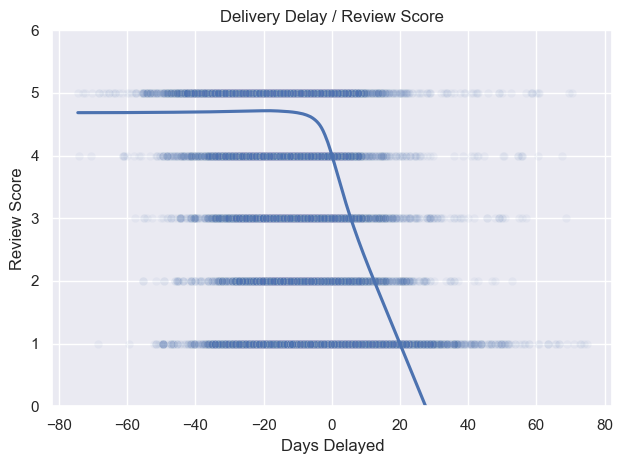

In [7]:
df_plot = df_reviews[
    (df_reviews["delivery_delay_days"] <= 75) & (df_reviews["delivery_delay_days"] >= -75)]
sns.scatterplot(data=df_plot, x="delivery_delay_days", y="review_score", alpha=0.05)
sns.regplot(data=df_plot, x="delivery_delay_days", y="review_score", lowess=True, scatter=False)
plt.ylim(0,6)
plt.xlabel("Days Delayed")
plt.ylabel("Review Score")
plt.title("Delivery Delay / Review Score")
plt.tight_layout()
plt.show()

#### Hypothesis Testing:  
Correlation between delivery delay and customer satisfaction (based on review score)

In [8]:
results = spearmanr(df_reviews["delivery_delay_days"], df_reviews["review_score"])

In [9]:
print(f"correlation: {results.statistic}")
print(f"p-value: {results.pvalue:.3f}")

correlation: -0.15215498561275279
p-value: 0.000


&uarr; &uarr; &uarr;  
This shows a small-moderate/negative correlation between delivery delay and review score

In [10]:
late_deliveries = df_reviews[df_reviews["delivery_delay_days"] > 0]

In [11]:
late_deliveries["review_score"].value_counts(normalize=True).sort_index()

review_score
1.0    0.469925
2.0    0.077303
3.0    0.111255
4.0    0.120066
5.0    0.221452
Name: proportion, dtype: float64

&uarr; &uarr; &uarr;  
More than half of the late deliveries gets a review score lower than 3

In [12]:
latency_rate = df_reviews.copy()
latency_rate["is_late"] = (latency_rate["delivery_delay_days"] > 0).astype(int)

In [13]:
region_map = {
    "AC": "North", "AP": "North", "AM": "North", "PA": "North", "RO": "North", "RR": "North", "TO": "North",
    "AL": "Northeast", "BA": "Northeast", "CE": "Northeast", "MA": "Northeast", "PB": "Northeast",
    "PE": "Northeast", "PI": "Northeast", "RN": "Northeast", "SE": "Northeast",
    "DF": "Midwest", "GO": "Midwest", "MT": "Midwest", "MS": "Midwest",
    "ES": "Southeast", "MG": "Southeast", "RJ": "Southeast", "SP": "Southeast",
    "PR": "South", "RS": "South", "SC": "South"
}

latency_rate["region"] = latency_rate["customer_state"].map(region_map)

In [14]:
latency_rate.groupby("region")["is_late"].mean().sort_values(ascending=False)

region
Northeast    0.139158
North        0.093280
Midwest      0.078254
Southeast    0.071431
South        0.067338
Name: is_late, dtype: float64

Delivery Latency Rates by State

In [15]:
state_counts = df_reviews["customer_state"].value_counts()
valid_states = state_counts[state_counts >= 300].index
latency_rate_state = latency_rate[latency_rate["customer_state"].isin(valid_states)]

In [16]:
latency_rate_state.groupby("customer_state")["is_late"].mean().sort_values(ascending=False).head(15)

customer_state
AL    0.235849
MA    0.198992
SE    0.158177
PI    0.154440
CE    0.152220
BA    0.133735
RJ    0.127989
TO    0.122977
ES    0.119417
PA    0.114120
PB    0.110345
MS    0.108776
RN    0.102317
PE    0.100694
SC    0.094265
Name: is_late, dtype: float64

Delivery Latency Rates by Seller

In [17]:
seller_counts = df_reviews["seller_id"].value_counts()
valid_sellers = seller_counts[seller_counts >= 10].index
latency_rate_seller = latency_rate[latency_rate["seller_id"].isin(valid_sellers)]

In [18]:
latency_rate_seller.groupby("seller_id")["is_late"].mean().sort_values(ascending=False).head(10)

seller_id
b1b3948701c5c72445495bd161b83a4c    0.642857
8d899e15a5925f097cca50faa49b15e3    0.600000
2709af9587499e95e803a6498a5a56e9    0.511111
fce62094ffe6a4009188ec44e681dfdd    0.454545
c37b2059d4f90d4feead554e5246565e    0.437500
38e6dada03429a47197d5d584d793b41    0.416667
02d35243ea2e497335cd0f076b45675d    0.375000
f76a3b1349b6df1ee875d1f3fa4340f0    0.375000
973f21788dfab357250f69a8dcb7ddee    0.368421
cb41bfbcbda0aea354a834ab222f9a59    0.363636
Name: is_late, dtype: float64